# Hotel Review Sentiment Analysis

## Setup
Jupyter Notebook, Python 3.11. Run all cells in order. The first run needs internet for missing packages, the NLTK lexicon and the pretrained model. A CUDA GPU is optional.

In [1]:
%pip install --disable-pip-version-check pandas==3.0.1 numpy==2.4.2 matplotlib==3.10.8 seaborn==0.13.2 nltk==3.9.2 scikit-learn==1.8.0 torch==2.5.1 transformers==4.41.2 optree==0.19.1

  Attempting uninstall: optree
    Found existing installation: optree 0.19.0
    Uninstalling optree-0.19.0:
      Successfully uninstalled optree-0.19.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import os
import re
import json
import hashlib
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

PROJECT_DIR = Path.cwd() if (Path.cwd() / 'archive').is_dir() else Path.cwd() / 'PROJECT'
DATA_PATH = PROJECT_DIR / 'archive' / 'Datafiniti_Hotel_Reviews.csv'
if not DATA_PATH.is_file():
    raise FileNotFoundError('Keep archive/Datafiniti_Hotel_Reviews.csv next to this notebook.')
NLTK_DIR = PROJECT_DIR / 'nltk_data'
NLTK_DIR.mkdir(exist_ok=True)
if str(NLTK_DIR) not in nltk.data.path:
    nltk.data.path.insert(0, str(NLTK_DIR))
try:
    nltk.data.find('sentiment/vader_lexicon.zip', paths=[str(NLTK_DIR)])
except LookupError:
    nltk.download('vader_lexicon', download_dir=str(NLTK_DIR), raise_on_error=True)

from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
os.environ['USE_TF'] = '0'
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from IPython.display import display

RESULTS_DIR = PROJECT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
LABELS = ['negative', 'positive']
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid')
print('Device:', 'CUDA' if torch.cuda.is_available() else 'CPU')

C:\Users\ezio9\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: CUDA


## Data
Dataset: Datafiniti Hotel Reviews [1]. A review is positive when its rating is at least 4 and negative when it is at most 2. Ratings between 2 and 4 are excluded. These are rating-derived labels, not manual text annotations.

In [3]:
raw = pd.read_csv(DATA_PATH)
df = raw[['reviews.text', 'reviews.rating']].copy()
df['source_row'] = raw.index
df['reviews.rating'] = pd.to_numeric(df['reviews.rating'], errors='coerce')
df = df.dropna(subset=['reviews.text', 'reviews.rating'])
df['text'] = df['reviews.text'].astype(str).str.strip()
df = df[df['text'].ne('') & df['reviews.rating'].between(1, 5)].copy()
valid_rows = len(df)
df = df[(df['reviews.rating'] <= 2) | (df['reviews.rating'] >= 4)].copy()
clear_rows = len(df)
df['sentiment'] = np.where(df['reviews.rating'] >= 4, 'positive', 'negative')
df['text_key'] = df['text'].str.casefold().str.replace(r'\s+', ' ', regex=True)
conflicts = df.groupby('text_key')['sentiment'].nunique()
conflicting_keys = conflicts[conflicts > 1].index
conflicting_rows = int(df['text_key'].isin(conflicting_keys).sum())
df = df[~df['text_key'].isin(conflicting_keys)].copy()
duplicate_rows = int(df['text_key'].duplicated().sum())
df = df.drop_duplicates('text_key').reset_index(drop=True)
cleaning = {
    'raw_rows': len(raw), 'invalid_or_missing_rows': len(raw) - valid_rows,
    'middle_rating_rows_excluded': valid_rows - clear_rows,
    'conflicting_label_rows_removed': conflicting_rows,
    'duplicate_rows_removed': duplicate_rows, 'final_rows': len(df)
}
display(pd.Series(cleaning, name='Count').to_frame())
display(df['sentiment'].value_counts().reindex(LABELS).to_frame('Count'))
display(df[['text', 'reviews.rating', 'sentiment']].head())

,Count
raw_rows,10000
invalid_or_missing_rows,1
middle_rating_rows_excluded,1561
conflicting_label_rows_removed,0
duplicate_rows_removed,16
final_rows,8422


,Count
sentiment,
negative,1152
positive,7270


,text,reviews.rating,sentiment
0,Our experience at Rancho Valencia was absolute...,5.0,positive
1,Amazing place. Everyone was extremely warm and...,5.0,positive
2,We booked a 3 night stay at Rancho Valencia to...,5.0,positive
3,Currently in bed writing this for the past hr ...,2.0,negative
4,I live in Md and the Aloft is my Home away fro...,5.0,positive


### Train, development and test sets
Use a stratified 70/15/15 split with seed 42. Normalized duplicate texts are removed before splitting. The training split supplies the majority baseline; the two sentiment models already have fixed rules or pretrained weights. Only development data select decision thresholds. Test data are evaluated after these choices are fixed. Hotels can appear in more than one split, so this measures new reviews, not unseen hotels.

In [4]:
train_df, remaining_df = train_test_split(df, test_size=0.30, stratify=df['sentiment'], random_state=SEED)
dev_df, test_df = train_test_split(remaining_df, test_size=0.50, stratify=remaining_df['sentiment'], random_state=SEED)
train_df, dev_df, test_df = [part.reset_index(drop=True) for part in (train_df, dev_df, test_df)]
for left, right in ((train_df, dev_df), (train_df, test_df), (dev_df, test_df)):
    assert set(left['text_key']).isdisjoint(set(right['text_key']))
split_counts = pd.DataFrame({name: part['sentiment'].value_counts().reindex(LABELS, fill_value=0)
                            for name, part in [('Train', train_df), ('Development', dev_df), ('Test', test_df)]}).T
split_counts['total'] = split_counts.sum(axis=1)
display(split_counts)
majority_label = train_df['sentiment'].mode()[0]
manifest = pd.concat([part[['source_row', 'sentiment']].assign(split=name)
                      for name, part in [('train', train_df), ('development', dev_df), ('test', test_df)]])
manifest.to_csv(RESULTS_DIR / 'split_manifest.csv', index=False)

sentiment,negative,positive,total
Train,806,5089,5895
Development,173,1090,1263
Test,173,1091,1264


## Method 1: VADER
VADER uses a sentiment dictionary and rules [2]. Keep punctuation, capitalization and negation words. Choose the compound-score threshold using development macro F1. The positive decision uses a score greater than or equal to the threshold.

In [5]:
sia = SentimentIntensityAnalyzer()
def vader_scores(texts):
    return np.array([sia.polarity_scores(text)['compound'] for text in texts])

def binary_labels(scores, threshold):
    return np.where(np.asarray(scores) >= threshold, 'positive', 'negative')

def choose_threshold(y_true, scores, candidates):
    rows = [{'threshold': threshold,
             'macro_f1': f1_score(y_true, binary_labels(scores, threshold), labels=LABELS, average='macro', zero_division=0)}
            for threshold in candidates]
    table = pd.DataFrame(rows)
    best = table.loc[table['macro_f1'].idxmax(), 'threshold']
    return float(best), table

dev_vader_scores = vader_scores(dev_df['text'])
vader_threshold, vader_dev_table = choose_threshold(dev_df['sentiment'], dev_vader_scores,
                                                   [-0.05, 0.0, 0.05, 0.2, 0.4, 0.6, 0.8])
display(vader_dev_table)
print('Selected VADER threshold:', vader_threshold)

,threshold,macro_f1
0,-0.05,0.741639
1,0.00,0.744568
2,0.05,0.753784
3,0.20,0.759035
4,0.40,0.766465
5,0.60,0.724714
6,0.80,0.641708


Selected VADER threshold: 0.4


## Method 2: RoBERTa
Use `cardiffnlp/twitter-roberta-base-sentiment`, trained for sentiment on tweets [3, 4]. Its three output classes are negative, neutral and positive. For this binary task, use `P(positive) / (P(positive) + P(negative))`, and select a threshold on development data. Every review receives a binary prediction, including reviews whose largest original score is neutral. This score is not a calibrated confidence estimate. Inputs longer than 512 tokens are truncated.

In [6]:
MODEL_NAME = 'cardiffnlp/twitter-roberta-base-sentiment'
MODEL_REVISION = 'daefdd1f6ae931839bce4d0f3db0a1a4265cd50f'
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION, local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, revision=MODEL_REVISION, use_safetensors=False, local_files_only=True)
except OSError:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, revision=MODEL_REVISION, use_safetensors=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()
assert model.config.id2label == {0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2'}

def prepare_roberta_text(text):
    return ' '.join('@user' if word.startswith('@') and len(word) > 1
                    else 'http' if word.startswith('http') else word
                    for word in text.split())

def roberta_scores(texts, batch_size=4):
    texts = [prepare_roberta_text(text) for text in texts]
    scores = []
    for start in range(0, len(texts), batch_size):
        tokens = tokenizer(texts[start:start + batch_size], padding=True,
                           truncation=True, max_length=512, return_tensors='pt').to(device)
        with torch.inference_mode():
            logits = model(**tokens).logits
            positive_scores = torch.softmax(logits[:, [0, 2]], dim=1)[:, 1]
        scores.extend(positive_scores.cpu().tolist())
    return np.array(scores)

dev_roberta_scores = roberta_scores(dev_df['text'])
roberta_threshold, roberta_dev_table = choose_threshold(dev_df['sentiment'], dev_roberta_scores,
                                                       [0.3, 0.4, 0.5, 0.6, 0.7])
display(roberta_dev_table)
print('Selected RoBERTa threshold:', roberta_threshold)

C:\Users\ezio9\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


,threshold,macro_f1
0,0.3,0.858701
1,0.4,0.846630
2,0.5,0.851373
3,0.6,0.848511
4,0.7,0.841201


Selected RoBERTa threshold: 0.3


## Results
Accuracy and macro F1 are calculated on the same held-out test reviews. Macro F1 gives the two classes equal weight. The majority baseline always predicts the most common training label.

In [7]:
test_results = test_df[['source_row', 'text', 'sentiment', 'reviews.rating']].copy()
test_results['vader_score'] = vader_scores(test_df['text'])
test_results['roberta_score'] = roberta_scores(test_df['text'])
test_results['Majority baseline'] = majority_label
test_results['VADER'] = binary_labels(test_results['vader_score'], vader_threshold)
test_results['RoBERTa'] = binary_labels(test_results['roberta_score'], roberta_threshold)

def evaluate(frame, prediction_column):
    return {'Model': prediction_column, 'N': len(frame),
            'Accuracy': accuracy_score(frame['sentiment'], frame[prediction_column]),
            'Macro F1': f1_score(frame['sentiment'], frame[prediction_column], labels=LABELS, average='macro', zero_division=0)}

metrics = pd.DataFrame([evaluate(test_results, name) for name in ['Majority baseline', 'VADER', 'RoBERTa']])
display(metrics.round(4))
for name in ['VADER', 'RoBERTa']:
    print(name)
    print(classification_report(test_results['sentiment'], test_results[name], labels=LABELS, zero_division=0))
selected_model = 'RoBERTa' if roberta_dev_table['macro_f1'].max() >= vader_dev_table['macro_f1'].max() else 'VADER'
print('Try it model (selected using development macro F1):', selected_model)

,Model,N,Accuracy,Macro F1
0,Majority baseline,1264,0.8631,0.4633
1,VADER,1264,0.8639,0.7466
2,RoBERTa,1264,0.9312,0.8574


VADER
              precision    recall  f1-score   support

    negative       0.50      0.67      0.57       173
    positive       0.94      0.89      0.92      1091

    accuracy                           0.86      1264
   macro avg       0.72      0.78      0.75      1264
weighted avg       0.88      0.86      0.87      1264

RoBERTa
              precision    recall  f1-score   support

    negative       0.74      0.77      0.75       173
    positive       0.96      0.96      0.96      1091

    accuracy                           0.93      1264
   macro avg       0.85      0.87      0.86      1264
weighted avg       0.93      0.93      0.93      1264

Try it model (selected using development macro F1): RoBERTa


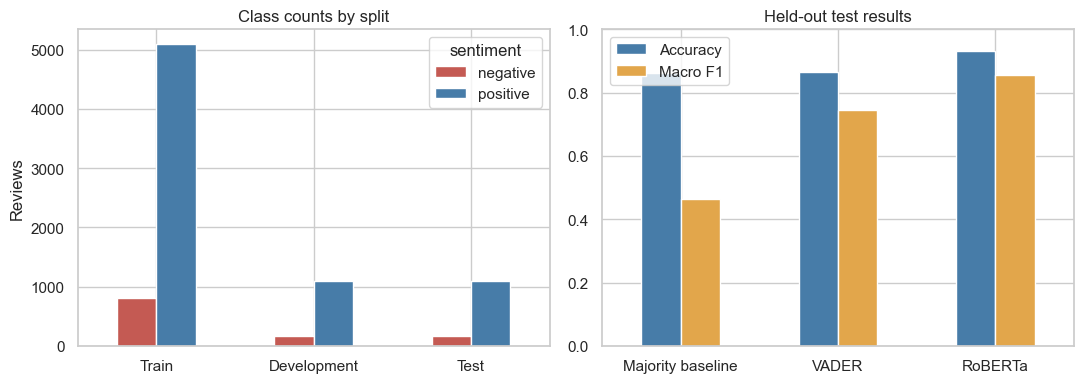

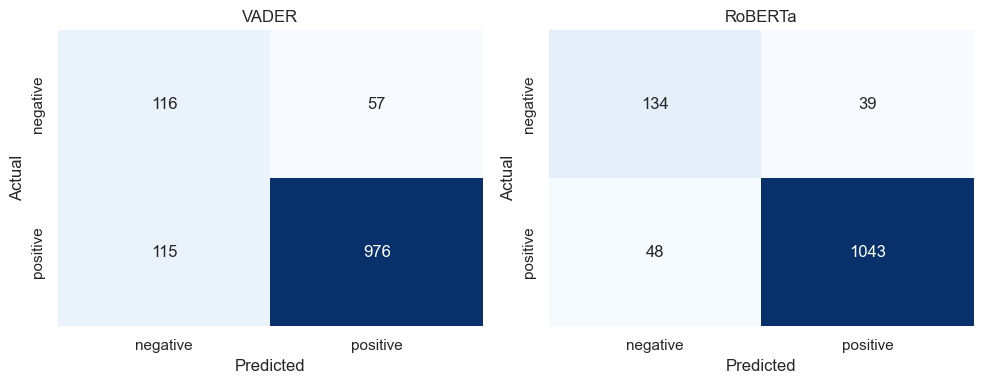

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
split_counts[LABELS].plot.bar(ax=axes[0], color=['#c45a53', '#477ca8'], rot=0)
axes[0].set(title='Class counts by split', ylabel='Reviews', xlabel='')
metrics.set_index('Model')[['Accuracy', 'Macro F1']].plot.bar(ax=axes[1], rot=0, color=['#477ca8', '#e2a64b'])
axes[1].set(title='Held-out test results', ylim=(0, 1), xlabel='')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'results.png', dpi=160, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ['VADER', 'RoBERTa']):
    cm = confusion_matrix(test_results['sentiment'], test_results[name], labels=LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set(title=name, xlabel='Predicted', ylabel='Actual')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()

### Experimental question: reviews containing negation
Which method has higher macro F1 on hotel reviews containing negation cues? The cue list is fixed before looking at test results: `no`, `not`, `never`, `neither`, `nor`, `without`, `cannot`, and contractions ending in `n't`. This identifies a review subset; it does not identify the scope of negation or prove that a mistake was caused by negation.

In [9]:
NEGATION_PATTERN = re.compile(r"\b(?:no|not|never|neither|nor|without|cannot)\b|n['’]t\b", re.IGNORECASE)
test_results['has_negation'] = test_results['text'].str.contains(NEGATION_PATTERN)
subset_rows = []
for subset_name, mask in [('With negation cue', test_results['has_negation']),
                          ('Without negation cue', ~test_results['has_negation'])]:
    subset = test_results[mask]
    if len(subset):
        for name in ['Majority baseline', 'VADER', 'RoBERTa']:
            row = evaluate(subset, name)
            row.update({'Subset': subset_name, 'Negative': int((subset['sentiment'] == 'negative').sum()),
                        'Positive': int((subset['sentiment'] == 'positive').sum())})
            subset_rows.append(row)
subset_metrics = pd.DataFrame(subset_rows)
display(subset_metrics.round(4))
negation_models = subset_metrics[(subset_metrics['Subset'] == 'With negation cue') &
                                 subset_metrics['Model'].isin(['VADER', 'RoBERTa'])]
if len(negation_models) == 2:
    best_score = negation_models['Macro F1'].max()
    winners = negation_models.loc[negation_models['Macro F1'] == best_score, 'Model'].tolist()
    print('Highest observed macro F1 on reviews with negation cues:', ', '.join(winners))
print('This is a descriptive comparison on one split, not a causal or significance test.')

,Model,N,Accuracy,Macro F1,Subset,Negative,Positive
0,Majority baseline,542,0.7435,0.4265,With negation cue,139,403
1,VADER,542,0.8284,0.7766,With negation cue,139,403
2,RoBERTa,542,0.9004,0.8706,With negation cue,139,403
3,Majority baseline,722,0.9529,0.4879,Without negation cue,34,688
4,VADER,722,0.8906,0.6490,Without negation cue,34,688
5,RoBERTa,722,0.9543,0.7619,Without negation cue,34,688


Highest observed macro F1 on reviews with negation cues: RoBERTa
This is a descriptive comparison on one split, not a causal or significance test.


### Wrong predictions
The following reviews are errors made by at least one method. Explanations of selected examples are included in the project report.

In [10]:
errors = test_results[(test_results['VADER'] != test_results['sentiment']) |
                      (test_results['RoBERTa'] != test_results['sentiment'])].copy()
display(errors[['source_row', 'text', 'sentiment', 'VADER', 'RoBERTa']].head(6))
errors.to_csv(RESULTS_DIR / 'errors.csv', index=False)

prepared_test = [prepare_roberta_text(text) for text in test_df['text']]
token_lengths = [len(tokenizer.encode(text, truncation=False, verbose=False)) for text in prepared_test]
truncated_test_reviews = int(sum(length > 512 for length in token_lengths))
print('Test reviews longer than 512 tokens:', truncated_test_reviews)

,source_row,text,sentiment,VADER,RoBERTa
1,3200,"Very good hotel, but the close proximity to th...",positive,negative,positive
29,1008,Bad: Expensive. Adding tha taxes become heavy....,positive,negative,negative
31,3188,"Very well positioned hotel, everything is clos...",positive,negative,positive
43,4242,They were very friendly when I booked my 246.0...,negative,positive,negative
57,5340,This hotel gets the job done. It gives you a p...,negative,positive,positive
60,902,Bad: Choice firmer pillows!. Good: Location ++...,positive,positive,negative


Test reviews longer than 512 tokens: 3


## Try it
Edit `new_review` and rerun the cell to classify an unfamiliar review. The chosen model and threshold were selected on development data. Mixed or neutral reviews are outside the intended binary task.

In [11]:
def predict_review(text, method=None):
    if not isinstance(text, str) or not text.strip():
        return 'Please enter a non-empty hotel review.'
    method = selected_model if method is None else method
    if method == 'VADER':
        score = vader_scores([text.strip()])[0]
        threshold = vader_threshold
    elif method == 'RoBERTa':
        score = roberta_scores([text.strip()])[0]
        threshold = roberta_threshold
    else:
        raise ValueError('Choose VADER or RoBERTa.')
    return str(binary_labels([score], threshold)[0])

new_review = 'The room was clean and the staff were helpful.'
print('Review:', new_review)
print('Model:', selected_model)
print('Prediction:', predict_review(new_review))
print('Empty-input check:', predict_review('   '))

Review: The room was clean and the staff were helpful.
Model: RoBERTa
Prediction: positive
Empty-input check: Please enter a non-empty hotel review.


### Demonstration examples
These AI-assisted demonstration sentences are separate from test scores. They do not replace the two original labelled examples required from each team member. Add member-authored examples to `team_examples.csv` with a name, text and expected label.

In [12]:
demo = pd.DataFrame([
    {'text': 'The room was clean and the staff were helpful.', 'expected': 'positive'},
    {'text': 'The room was dirty and the staff were rude.', 'expected': 'negative'},
    {'text': 'The room was not clean and I could not sleep.', 'expected': 'negative'},
    {'text': 'There was no noise at night and the bed was comfortable.', 'expected': 'positive'}
])
demo['prediction'] = [predict_review(text) for text in demo['text']]
display(demo)
team_path = PROJECT_DIR / 'team_examples.csv'
if team_path.is_file():
    team_examples = pd.read_csv(team_path)
    if len(team_examples):
        assert team_examples[['member', 'text', 'expected']].notna().all().all()
        assert team_examples['expected'].isin(LABELS).all()
        assert team_examples['text'].str.strip().ne('').all()
        team_examples['prediction'] = [predict_review(text) for text in team_examples['text']]
        display(team_examples)
    else:
        print('Member-authored examples have not been supplied yet.')

,text,expected,prediction
0,The room was clean and the staff were helpful.,positive,positive
1,The room was dirty and the staff were rude.,negative,negative
2,The room was not clean and I could not sleep.,negative,negative
3,There was no noise at night and the bed was co...,positive,positive


Member-authored examples have not been supplied yet.


### Save results
The files below record the split, predictions, thresholds and environment used for the report.

In [13]:
test_results.to_csv(RESULTS_DIR / 'test_predictions.csv', index=False)
metrics.to_csv(RESULTS_DIR / 'metrics.csv', index=False)
subset_metrics.to_csv(RESULTS_DIR / 'negation_metrics.csv', index=False)
split_counts.to_csv(RESULTS_DIR / 'split_counts.csv')
demo.to_csv(RESULTS_DIR / 'demo_predictions.csv', index=False)
vader_dev_table.to_csv(RESULTS_DIR / 'vader_development.csv', index=False)
roberta_dev_table.to_csv(RESULTS_DIR / 'roberta_development.csv', index=False)
packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'nltk', 'scikit-learn', 'torch', 'transformers', 'optree']
run_info = {'seed': SEED, 'cleaning': cleaning, 'dataset_sha256': hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
            'model': MODEL_NAME, 'revision': MODEL_REVISION, 'device': str(device),
            'vader_threshold': vader_threshold, 'roberta_threshold': roberta_threshold,
            'selected_model': selected_model, 'truncated_test_reviews': truncated_test_reviews,
            'packages': {name: importlib.metadata.version(name) for name in packages}}
(RESULTS_DIR / 'run_info.json').write_text(json.dumps(run_info, indent=2), encoding='utf-8')
assert test_results[['VADER', 'RoBERTa']].notna().all().all()
assert len(test_results) == len(test_df)
print('Saved results in:', RESULTS_DIR.name)

Saved results in: results


## Sources
1. Datafiniti. *Hotel Reviews*. https://www.kaggle.com/datasets/datafiniti/hotel-reviews
2. Hutto, C. J., and Gilbert, E. (2014). *VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text*. ICWSM. NLTK implementation: https://www.nltk.org/api/nltk.sentiment.vader.html
3. Barbieri, F., Camacho-Collados, J., Espinosa Anke, L., and Neves, L. (2020). *TweetEval: Unified Benchmark and Comparative Evaluation for Tweet Classification*. https://aclanthology.org/2020.findings-emnlp.148/
4. CardiffNLP. *twitter-roberta-base-sentiment model card*. https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment

Starting point: the existing Sentiment Analysis notebook supplied in this project folder; its original authorship was not independently established. OpenAI Codex assisted with code corrections, experiment setup, testing, demonstration examples and document preparation. Team members must review and understand the submitted work and credit any additional reused material.